In [ ]:
import folium

# ── Step 3: Create interactive map with arrow markers ────────────────────────
def get_arrow_icon(direction, size=30):
    """Create a rotating arrow icon based on wind direction."""
    direction_map = {
        'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
        'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
        'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
        'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
    }
    
    rotation = direction_map.get(str(direction).upper().strip(), 0)
    
    # SVG arrow pointing upward (will be rotated)
    svg = """<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24">
        <polygon points="12,2 22,22 12,18 2,22" fill="#4a90d9" stroke="#1a1a2e" stroke-width="1.5"/>
    </svg>"""
    
    html = f"""
    <div style="
        transform: rotate({rotation}deg);
        width: {size}px;
        height: {size}px;
        display: flex;
        align-items: center;
        justify-content: center;
    ">
        {svg}
    </div>
    """
    
    return folium.DivIcon(html=html)

wind_map = folium.Map(location=[51.2538, -85.3232], zoom_start=6, tiles='CartoDB positron')

for _, row in stations.iterrows():
    speed = row['speed']
    direction = row['direction']
    
    popup_html = (f"<b>{row['LOCATION_NAME']}</b><br>"
                  f"<b>Wind Speed (Yearly):</b> {speed} km/h<br>"
                  f"<b>Wind Direction:</b> {direction}")
    
    # Size arrow based on wind speed
    try:
        arrow_size = max(int(float(speed) * 1.5), 20)
    except (ValueError, TypeError):
        arrow_size = 20
    
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_html, max_width=250),
        icon=get_arrow_icon(direction, size=arrow_size),
    ).add_to(wind_map)

wind_map.save('../api/wind_map_yearly.html')
print("Saved to ../results/wind_map_yearly.html")
display(wind_map)

Saved to wind_map_yearly.html


Source shape (downsampled): (612, 836)
WGS84 shape: (612, 836)
Actual bounds: W=-95.20, S=41.60, E=-74.30, N=56.90
Min/Max: 4.29, 10.10
Image encoded, size: 615 KB
Saved to wind_speed_heatmap.html


C:\Users\arsen\AppData\Local\Temp\ipykernel_21380\1546686881.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('YlOrRd')



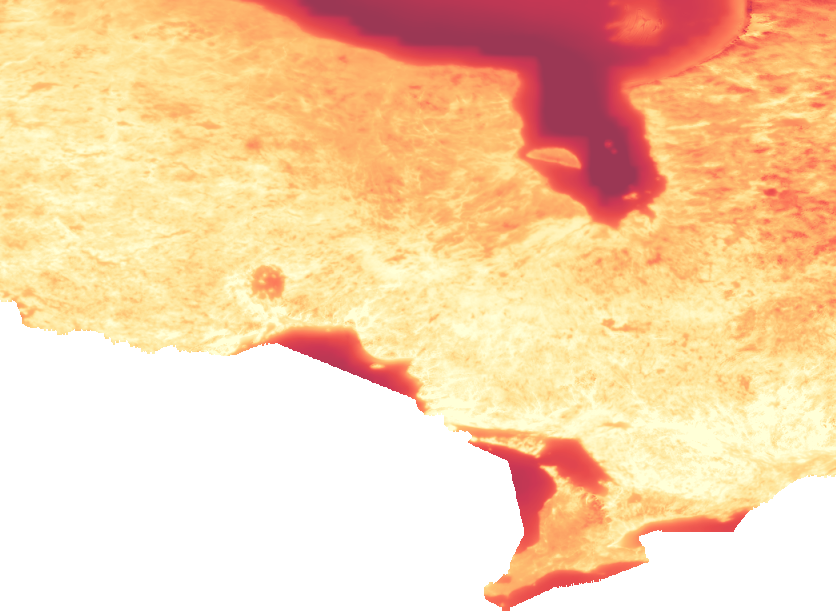

In [ ]:
import rasterio
import rasterio.transform
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_bounds
from rasterio.windows import from_bounds as window_from_bounds
from rasterio.transform import array_bounds as raster_array_bounds
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from PIL import Image
import io
import base64
import folium
from folium.raster_layers import ImageOverlay

# Ontario bounding box (WGS84)
ON_WEST, ON_EAST, ON_SOUTH, ON_NORTH = -95.2, -74.3, 41.6, 56.9

with rasterio.open('./data/CAN_wind-speed_100m.tif') as src:
    src_crs = src.crs
    nodata = src.nodata

    # Convert Ontario WGS84 bounds into the raster's native CRS
    src_on_bounds = transform_bounds('EPSG:4326', src_crs, ON_WEST, ON_SOUTH, ON_EAST, ON_NORTH)

    # Read only the Ontario window (not all of Canada)
    win = window_from_bounds(*src_on_bounds, src.transform).round_lengths().round_offsets()
    win = win.intersection(rasterio.windows.Window(0, 0, src.width, src.height))
    src_h = int(win.height)
    src_w = int(win.width)

    # Downsample to ~10% during read to keep memory manageable
    out_h = max(100, src_h // 10)
    out_w = max(100, src_w // 10)
    data_src = src.read(
        1, window=win, out_shape=(out_h, out_w),
        resampling=Resampling.average
    ).astype(np.float32)
    win_transform = src.window_transform(win)

# Replace nodata with NaN
if nodata is not None:
    data_src[data_src == nodata] = np.nan

print(f"Source shape (downsampled): {data_src.shape}")

# Rebuild the transform for the downsampled array
# (same geographic extent as the window, but fewer pixels)
src_extent = raster_array_bounds(src_h, src_w, win_transform)  # (west, south, east, north)
win_transform_ds = rasterio.transform.from_bounds(*src_extent, out_w, out_h)

# Reproject the Ontario tile to WGS84
dst_transform, dst_width, dst_height = calculate_default_transform(
    src_crs, 'EPSG:4326', out_w, out_h, *src_extent
)
data_wgs84 = np.full((dst_height, dst_width), np.nan, dtype=np.float32)
reproject(
    source=data_src,
    destination=data_wgs84,
    src_transform=win_transform_ds,
    src_crs=src_crs,
    dst_transform=dst_transform,
    dst_crs='EPSG:4326',
    resampling=Resampling.bilinear,
    src_nodata=np.nan,
    dst_nodata=np.nan,
)

# Derive the actual lat/lon bounds from the output transform — not hardcoded
out_west, out_south, out_east, out_north = raster_array_bounds(dst_height, dst_width, dst_transform)
print(f"WGS84 shape: {data_wgs84.shape}")
print(f"Actual bounds: W={out_west:.2f}, S={out_south:.2f}, E={out_east:.2f}, N={out_north:.2f}")
print(f"Min/Max: {np.nanmin(data_wgs84):.2f}, {np.nanmax(data_wgs84):.2f}")

# Normalize using 2nd–98th percentile of valid data
valid = data_wgs84[~np.isnan(data_wgs84) & (data_wgs84 > 0)]
vmin, vmax = np.nanpercentile(valid, [2, 98])
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = get_cmap('YlOrRd')

# Build RGBA image
normalized = norm(np.nan_to_num(data_wgs84, nan=0.0))
rgba = cmap(normalized)
alpha = np.where((~np.isnan(data_wgs84)) & (data_wgs84 > 0), 200, 0).astype(np.uint8)
img_array = (rgba[:, :, :3] * 255).astype(np.uint8)
img_rgba = np.dstack([img_array, alpha])

img = Image.fromarray(img_rgba, mode='RGBA')
buf = io.BytesIO()
img.save(buf, format='PNG')
buf.seek(0)
img_b64 = "data:image/png;base64," + base64.b64encode(buf.read()).decode('utf-8')
print(f"Image encoded, size: {len(img_b64) // 1024} KB")

# Map centered on Ontario
wind_speed_map = folium.Map(location=[49.25, -84.5], zoom_start=5, tiles='CartoDB positron')

# Use the ACTUAL bounds derived from the reprojected transform
bounds_folium = [[out_south, out_west], [out_north, out_east]]

ImageOverlay(
    image=img_b64,
    bounds=bounds_folium,
    opacity=0.6,
    name='Wind Speed (100m)',
    cross_origin=False,
).add_to(wind_speed_map)

folium.LayerControl().add_to(wind_speed_map)
wind_speed_map.save('../api/wind_speed_heatmap.html')
print("Saved to ../api/wind_speed_heatmap.html")
display(wind_speed_map)